<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/exercises/07_mpc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model predictive control for autonomous lane following

In this notebook, you'll build a Model Predictive Controller (MPC) for an autonomous vehicle navigating a curved road. You'll start with basic geometry and visualization, then progressively add complexity: constraints, disturbances, and obstacles.

## Car dynamics
We model the car as a double integrator in both $x$ and $y$ directions.

**State:** $\mathbf{x} = [p_x, v_x, p_y, v_y]^\top$

**Input:** $\mathbf{u} = [a_x, a_y]^\top$

**Continuous dynamics:**
$$
\dot{p}_x = v_x, \quad \dot{v}_x = a_x, \quad \dot{p}_y = v_y, \quad \dot{v}_y = a_y
$$


In [1]:
import scipy
from typing import Optional, Tuple
import functools
import cvxpy as cp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
import equinox as eqx

# Configure plotting
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [2]:
# Helper functions. Please take a look at what functions are defined here. You will need to use some of these in your MPC implementation.
# Just run this cell.

# helper function for road geometry construction
def create_curved_centerline(s_values: np.ndarray, amplitude: float = 2.0, angular_frequency: float = 0.1) -> np.ndarray:
    """
    Create a sinusoidal curved road centerline.

    Args:
        s_values: Array of arc length parameters

    Returns:
        centerline: (N, 2) array of [x, y] positions along centerline
    """
    y = amplitude * jnp.sin(angular_frequency * s_values)  # amplitude=2m, wavelength~63m
    centerline = jnp.stack([s_values, y], axis=1)
    return centerline


# helper function to extract lane boundaries from centerline
@eqx.filter_jit
def get_lane_boundaries(
    centerline: np.ndarray, lane_width: float
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute lane boundaries given centerline and width.

    Args:
        centerline: (N, 2) array of [x, y] centerline positions
        lane_width: Half-width of the lane (meters)

    Returns:
        left_boundary: (N, 2) array of left lane boundary
        right_boundary: (N, 2) array of right lane boundary
    """
    # Compute tangent vectors (forward differences)
    tangents = jnp.diff(centerline, axis=0, prepend=centerline[0:1])
    tangent_norms = jnp.linalg.norm(tangents, axis=1, keepdims=True)
    tangent_norms = jnp.maximum(tangent_norms, 1e-6)  # Avoid division by zero
    tangents_normalized = tangents / tangent_norms

    # Normal vectors (perpendicular to tangents, 90° counterclockwise)
    normals = jnp.stack([-tangents_normalized[:, 1], tangents_normalized[:, 0]], axis=1)

    # Lane boundaries
    left_boundary = centerline + lane_width * normals
    right_boundary = centerline - lane_width * normals

    return left_boundary, right_boundary

# helper function to generate reference trajectory by sampling centerline ahead of current position
@eqx.filter_jit
def get_centerline_reference(
    state: float,
    centerline: np.ndarray,
    horizon: int,
    dt: float,
    desired_velocity: float,
) -> jnp.ndarray:
    """
    Generate reference trajectory by sampling centerline ahead of current position.

    Args:
        centerline: (N, 2) array of centerline positions
        state: Current x-position of vehicle
        horizon: Prediction horizon length
        dt: Time step
        desired_velocity: Desired forward velocity

    Returns:
        reference: (horizon+1, 4) array of [px, vx, py, vy] reference states
    """
    centerline_frenet, _ = jax.vmap(global_to_frenet, [0, None])(
        centerline[:, [0, 2]], centerline
    )
    # compute desired s steps given desired velocity
    ds = desired_velocity * dt
    # get current frenet coordinates
    current_frenet, _ = global_to_frenet(state[jnp.array([0, 2])], centerline)
    # Predict future s-positions assuming constant forward velocity
    future_s = current_frenet[0] + jnp.arange(horizon) * ds
    # Find corresponding positions by interpolating centerline in frenet
    future_x = jnp.interp(future_s, centerline_frenet[:, 0], centerline[:, 0])
    future_y = jnp.interp(future_s, centerline_frenet[:, 0], centerline[:, 2])

    future_dx = jnp.diff(future_x)
    future_dy = jnp.diff(future_y)
    future_theta = jnp.arctan2(future_dy, future_dx)
    _future_vx = desired_velocity * jnp.cos(future_theta)
    _future_vy = desired_velocity * jnp.sin(future_theta)

    future_vx = jnp.concatenate([_future_vx, jnp.array([_future_vx[-1]])])
    future_vy = jnp.concatenate([_future_vy, jnp.array([_future_vy[-1]])])

    # Build reference state [px, vx, py, vy]
    reference = jnp.stack(
        [
            future_x,
            future_vx,
            future_y,
            future_vy,
        ],
        axis=-1,
    )
    return reference

# helper function to plot lane
def plot_lane(
    ax, centerline: jnp.ndarray, lane_width: float, color="lightgray", alpha=0.5
):
    """
    Plot lane as a filled region around centerline.
    """
    left_boundary, right_boundary = get_lane_boundaries(centerline, lane_width)

    # Create closed polygon for filling
    boundary = jnp.vstack([left_boundary, right_boundary[::-1]])
    ax.fill(boundary[:, 0], boundary[:, 1], color=color, alpha=alpha, label="Lane")

    # Plot centerline
    ax.plot(
        centerline[:, 0],
        centerline[:, 1],
        "k--",
        linewidth=1,
        alpha=0.5,
        label="Centerline",
    )

# helper function to plot trajectory
def plot_trajectory(
    ax, positions: jnp.ndarray, color="blue", label="Trajectory", linewidth=2, alpha=1.0
):
    """
    Plot vehicle trajectory.
    """
    ax.plot(
        positions[:, 0],
        positions[:, 1],
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        label=label,
    )

    # Mark start and end
    ax.plot(positions[0, 0], positions[0, 1], "go", markersize=8, label="Start")
    ax.plot(positions[-1, 0], positions[-1, 1], "ro", markersize=8, label="End")

# helper function to plot potholes
def plot_potholes(ax, pothole_positions: jnp.ndarray, pothole_radii: jnp.ndarray):
    """
    Plot pothole locations as small circles.
    """
    for i in range(pothole_positions.shape[0]):
        px, py = pothole_positions[i]
        radius = pothole_radii[i]
        circle = Circle((px, py), radius, color="orange", alpha=0.6, zorder=5)
        ax.add_patch(circle)
        if i == 0:
            circle.set_label("Potholes")


# helper function to plot scene
def plot_scene(
    centerline: jnp.ndarray,
    lane_width: float,
    trajectory: Optional[jnp.ndarray] = None,
    reference: Optional[jnp.ndarray] = None,
    potholes: Optional[Tuple[jnp.ndarray, jnp.ndarray]] = None,
    title: str = "Road Scene",
    xlim: Optional[Tuple[float, float]] = None,
    ylim: Optional[Tuple[float, float]] = None,
):
    """
    Create a complete scene visualization.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    # Plot lane
    plot_lane(ax, centerline, lane_width)

    # Plot reference trajectory if provided
    if reference is not None:
        ax.plot(
            reference[:, 0],
            reference[:, 2],
            "g--",
            linewidth=1.5,
            alpha=0.7,
            label="Reference",
        )

    # Plot actual trajectory if provided
    if trajectory is not None:
        positions = trajectory[:, [0, 2]]  # Extract [px, py]
        plot_trajectory(ax, positions, color="blue", label="Actual")

    # Plot potholes if provided
    if potholes is not None:
        plot_potholes(ax, *potholes)

    ax.set_xlabel("X Position (m)")
    ax.set_ylabel("Y Position (m)")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)

    plt.tight_layout()
    return fig, ax


# helper function to plot state trajectories
def plot_state_trajectories(trajectory, N_sim, dt):
    # Plot state variables over time
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))

    ts = np.arange(N_sim + 1) * dt

    axes[0, 0].plot(ts, trajectory[:, 0], "b-", linewidth=2)
    axes[0, 0].set_xlabel("Time (s)")
    axes[0, 0].set_ylabel("$p_x$ (m)")
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_title("Longitudinal Position")

    axes[0, 1].plot(ts, trajectory[:, 1], "b-", linewidth=2)
    axes[0, 1].set_xlabel("Time (s)")
    axes[0, 1].set_ylabel("$v_x$ (m/s)")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_title("Longitudinal Velocity")

    axes[1, 0].plot(ts, trajectory[:, 2], "r-", linewidth=2)
    axes[1, 0].set_xlabel("Time (s)")
    axes[1, 0].set_ylabel("$p_y$ (m)")
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_title("Lateral Position")

    axes[1, 1].plot(ts, trajectory[:, 3], "r-", linewidth=2)
    axes[1, 1].set_xlabel("Time (s)")
    axes[1, 1].set_ylabel("$v_y$ (m/s)")
    axes[1, 1].set_ylabel("$v_y$ (m/s)")
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_title("Lateral Velocity")

    plt.tight_layout()
    plt.show()

# helper function to plot controls
def plot_controls(controls, N_sim, dt):
    # Plot control variables over time
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    ts = np.arange(N_sim) * dt

    axes[0].plot(ts, controls[:, 0], "b-", linewidth=2)
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("$a_x$ (m/s²)")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title("Longitudinal Acceleration")

    axes[1].plot(ts, controls[:, 1], "b-", linewidth=2)
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("$a_y$ (m/s²)")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_title("Lateral Acceleration")

    plt.tight_layout()
    plt.show()


# helper function to convert global coordinates to frenet coordinates
@jax.jit
def global_to_frenet(
    position: jnp.ndarray, centerline: jnp.ndarray
) -> Tuple[float, float]:
    """
    Convert global (x, y) to Frenet coordinates (s, d).
    s = longitudinal distance along centerline
    d = lateral distance from centerline (positive = left)
    """
    # Find closest point on centerline
    distances = jnp.linalg.norm(centerline - position, axis=1)
    idx = jnp.argmin(distances)
    dx = jnp.diff(centerline, axis=0, prepend=centerline[:1])
    ds = jnp.concatenate((jnp.array([0]), jnp.linalg.norm(dx, axis=1)))
    frenet_s = jnp.cumsum(ds)

    # Compute signed lateral distance
    closest_point = centerline[idx]
    before_point = jax.lax.cond(
        idx > 0, lambda x: centerline[x - 1], lambda x: closest_point, idx
    )
    after_point = jax.lax.cond(
        idx < len(centerline) - 1,
        lambda x: centerline[x + 1],
        lambda x: closest_point,
        idx,
    )

    before_distance = jnp.linalg.norm(before_point - position)
    after_distance = jnp.linalg.norm(after_point - position)

    second_closest_point_idx = jnp.argmin(jnp.array([before_distance, after_distance]))
    p0 = jax.lax.cond(
        second_closest_point_idx == 0, lambda: before_point, lambda: closest_point
    )
    p1 = jax.lax.cond(
        second_closest_point_idx == 0, lambda: closest_point, lambda: after_point
    )
    idx_tmp = jax.lax.cond(
        second_closest_point_idx == 0,
        lambda x: jax.lax.cond(x > 0, lambda y: y - 1, lambda y: y, x),
        lambda x: x,
        idx,
    )

    direction = p1 - p0
    direction /= jnp.linalg.norm(direction + 1e-8)
    gamma_opt = -jnp.dot((p0 - position), direction)
    centerline_opt = p0 + gamma_opt * direction
    s = frenet_s[idx_tmp] + jnp.abs(gamma_opt)

    tangent = p1 - p0
    tangent /= jnp.linalg.norm(tangent) + 1e-8
    normal = jnp.array([-tangent[1], tangent[0]])  # 90° counterclockwise

    # Signed distance (positive = left of centerline)
    offset_vector = position - centerline_opt
    d = jnp.dot(offset_vector, normal)

    return jnp.array([s, d]), centerline_opt


# helper function to simulate open loop trajectory
def simulate_open_loop(
    initial_state: np.ndarray,
    controls: np.ndarray,
    dynamics_func,
    dt: float,
) -> np.ndarray:
    """
    Simulate trajectory given initial state and control sequence.

    Args:
        initial_state: (n,) array of initial state
        controls: (N, m) array of control inputs
        dynamics_func: Function(state, control, params) -> next_state
        params: Additional parameters for dynamics function
        dt: Time step
    Returns:
        trajectory: (N+1, n) array of states over time
    """

    def _scan_func(carry, u):
        state = carry
        next_state = dynamics_func(state, u, dt)
        return next_state, next_state

    _, trajectory = jax.lax.scan(_scan_func, initial_state, controls)
    trajectory = jnp.vstack([initial_state, trajectory])
    return trajectory

# helper function to simulate closed loop trajectory
def simulate_closed_loop(
    initial_state: np.ndarray,
    policy,
    n_steps: int,
    dynamics_func,
    dt: float,
    has_numpy=False,
) -> np.ndarray:
    """
    Simulate trajectory given initial state and control sequence.

    Args:
        initial_state: (n,) array of initial state
        policy: Function(state) -> control
        n_steps: Number of time steps to simulate
        dynamics_func: Function(state, control, dt) -> next_state
        dt: Time step
    Returns:
        trajectory: (N+1, n) array of states over time
    """

    def _scan_func(carry, _):
        state = carry
        control = policy(state)
        next_state = dynamics_func(state, control, dt)
        return next_state, next_state

    def scan(f, init, xs, length=None):
        if xs is None:
            xs = [None] * length
        carry = init
        ys = []
        for x in xs:
            carry, y = f(carry, x)
            ys.append(y)
        return carry, np.stack(ys)

    if has_numpy:
        _, trajectory = scan(_scan_func, initial_state, None, length=n_steps)
    else:
        _, trajectory = jax.lax.scan(_scan_func, initial_state, None, length=n_steps)
    trajectory = jnp.vstack([initial_state, trajectory])
    return trajectory

### Define and plot curved lane

First, let us construct a curvy road for our autonomous car to operate in.
Just run the cell below to generate the curvy road and visualize it.




Created centerline with 300 points
X range: [0.0, 150.0] m
Y range: [-5.0, 5.0] m


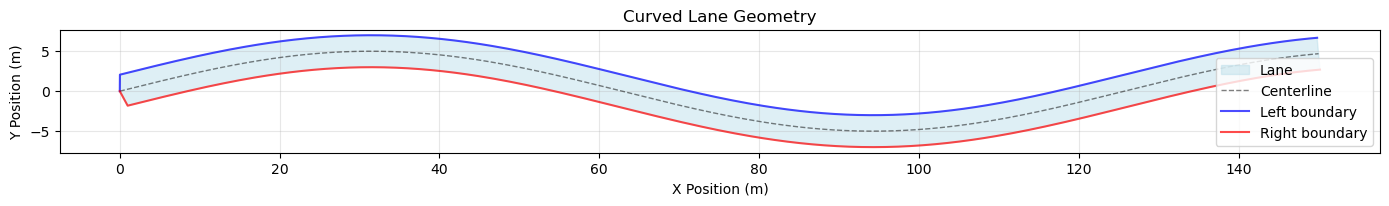

In [6]:
# Define road parameters
# feel free to adjust these parameters to make the road wider or narrower, or make the curve more or less pronounced
LANE_WIDTH = 2.0  # Half-width of the lane (meters)
ROAD_LENGTH = 150.0  # Total length of the road (meters)
ANGULAR_FREQUENCY = 0.05  # Angular frequency of the sine wave
AMPLITUDE = 5.0  # Amplitude of the sine wave

# Create centerline: y = AMPLITUDE * sin(ANGULAR_FREQUENCY * x)
n_points_centerline = 300
s_values = np.linspace(0, ROAD_LENGTH, n_points_centerline)
centerline = create_curved_centerline(s_values, AMPLITUDE, ANGULAR_FREQUENCY)

print(f"Created centerline with {len(centerline)} points")
print(f"X range: [{centerline[:, 0].min():.1f}, {centerline[:, 0].max():.1f}] m")
print(f"Y range: [{centerline[:, 1].min():.1f}, {centerline[:, 1].max():.1f}] m")

# Compute lane boundaries
left_boundary, right_boundary = get_lane_boundaries(centerline, LANE_WIDTH)

# Plot the lane
fig, ax = plt.subplots(figsize=(14, 6))

plot_lane(ax, centerline, LANE_WIDTH, color="lightblue", alpha=0.4)
ax.plot(
    left_boundary[:, 0],
    left_boundary[:, 1],
    "b-",
    linewidth=1.5,
    alpha=0.7,
    label="Left boundary",
)
ax.plot(
    right_boundary[:, 0],
    right_boundary[:, 1],
    "r-",
    linewidth=1.5,
    alpha=0.7,
    label="Right boundary",
)

ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Curved Lane Geometry")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### (a) Set up discrete time dynamics
Define the discrete time dynamics for the car using Euler integration with timestep size $\Delta t = 0.1$.

In [7]:


def car_dynamics_dt(state: jnp.ndarray, control: jnp.ndarray, dt: float) -> jnp.ndarray:
    """
    Discrete time dynamics for the car using Euler integration.

    Args:
        state: (4,) array [px, vx, py, vy]
        control: (2,) array [ax, ay]
        params: Tuple containing any necessary parameters (e.g., mass)
        dt: Time step size
    Returns:
        next_state: (4,) array of next state
    """
    px, vx, py, vy = state
    ax, ay = control

    ###### add your code here
    next_state = jnp.array([
        px + vx * dt, # next px
        vx + ax * dt, # next vx
        py + vy * dt, # next py
        vy + ay * dt  # next vy
    ])
    ###### end of add your code here


    return next_state

Check that your dynamics function works by simulating the system with zero control input.

Take a look at the code to familiarize yourself with some of the helper functions.

In [ ]:
# Run this cell after defining car_dynamics_dt above.

N_sim = 100 # number of time steps to simulate
dt = 0.1  # time step

# Start at origin, 5 m/s forward, centered
initial_state = jnp.array([0.0, 5.0, 0.0, 0.0]) # px, vx, py, vy

# Zero acceleration inputs for N_sim time steps
controls = jnp.array([[0.0, 0.0]] * N_sim)

# simulate open loop trajectory
trajectory_open_loop = simulate_open_loop(
    initial_state=initial_state,
    controls=controls,
    dynamics_func=car_dynamics_dt,
    dt=dt,
)

fig, ax = plot_scene(
    centerline,
    LANE_WIDTH,
    trajectory=trajectory_open_loop,
    title="Open-Loop Behavior (Zero Input)",
    xlim=(0, 60),
    ylim=(-3, 4),
)

plot_state_trajectories(trajectory_open_loop, N_sim, dt)


**Observe:** The car moves in a straight line (constant velocity, no steering). It doesn't follow the curved road. This is to be expected

---

### (b) Simple proportional controller

Now, let's try a simple proportional controller: $$a_y = k_p (p_y - {\text{center}}_y(p_x))$$

This tries to "pull" the car back toward the centerline at longitudinal position $p_x$.

Choose $K_p$ to be the gain corresponding to the infinite discrete-time LQR gain.
That is, solve for $K_\infty$ for the system, and then select the gain corresponsing to the $a_y$ - $p_y$ entry.

Assume that $a_x=0$ (i.e., maintain velocity in the $x$ direction).


In [ ]:
# Simple proportional controller with given centerline and gain. Run this cell as is.
@jax.jit
def proportional_controller(
    state: jnp.ndarray, centerline: jnp.ndarray, kp: float = 2.0
) -> jnp.ndarray:
    """
    Simple proportional controller to keep car centered in lane.

    Args:
        state: (4,) array [px, vx, py, vy]
        centerline: (N, 2) array of centerline positions
        kp: Proportional gain for lateral control

    Returns:
        control: (2,) array [acceleration, steering_angle]
    """

    # Extract state variables
    px, vx, py, vy = state

    # Find desired lateral position (centerline) using interp
    py_center = jnp.interp(px, centerline[:, 0], centerline[:, 1])

    # Proportional control law
    ay = kp * (py - py_center)


    # No longitudinal control (maintain speed)
    ax = 0.0


    return jnp.array([ax, ay])


In [ ]:
# TODO: Compute the LQR gain $K_\infty$ for the discrete-time double integrator
##### add your code here
# define dt
# define matrices, A, B, Q, R
# compute Pinf using scipy.linalg.solve_discrete_are
# compute Kinf using K = -(R + B.T @ Pinf @ B)^-1 @ (B.T @ Pinf @ A)
###### end of add your code here



Let's evaluate the performance of your proportional controller.

Execute the cell below to simulate the closed-loop system using the proportional controller you just defined, and observe how the vehicle tracks the reference path.

In [ ]:
# Run this cell after defining proportional_controller above.
N_sim = 150

# Start at origin, 5 m/s forward, centered
initial_state = jnp.array([0.0, 5.0, 0.0, 0.0])

# define policy
# setting kp to be the relevant value corresponding to (ay, py)
kp = Kinf[1, 2]  # Setting gain parameter to the LQR gain for lateral position
policy = functools.partial(proportional_controller, centerline=centerline, kp=kp)

# simulate closed loop trajectory
trajectory_proportional = simulate_closed_loop(
    initial_state=initial_state,
    policy=policy,
    n_steps=N_sim,
    dynamics_func=car_dynamics_dt,
    dt=dt,
)

controls_proportional = jax.vmap(policy)(trajectory_proportional[:-1])

fig, ax = plot_scene(
    centerline,
    LANE_WIDTH,
    trajectory=trajectory_proportional,
    title="Open-Loop Behavior (Zero Input)",
    xlim=(0, 60),
    ylim=(-3, 4),
)

plot_state_trajectories(trajectory_proportional, N_sim, dt)

plot_controls(controls_proportional, N_sim, dt)

**Observe:** The car still is not great at tracking the curvy road. You should observe significant ocsillations, resulting in the car going off the road.

---

### (c)(i) Simple look-ahead controller

We improve our proportional controller by introducing a notion of *look ahead* where instead of considering the current lateral error when computing the controller, we consider the projected lateral error at some look ahead distance $d_\mathrm{la}$ in front of the car.

This is similar to how humans drive. We look out the windshield to see what is ahead of use and that will determine our steering/acceleration in order to stay in our lane. We do not look straight down at our feet (suppose there is a glass bottom).

The projected look ahead lateral distance is

$$ p_y^\mathrm{proj} = p_y + d_\mathrm{la}\sin(\theta), \quad \theta = \arctan\frac{v_y}{v_x}$$

$$p_x^\mathrm{proj} = p_x + d_\mathrm{la}\cos(\theta)$$

$$ a_y = k_p(p_y^\mathrm{proj} - \text{center}_y(p_x^\mathrm{proj}))$$

Assume that $a_x=0$ (i.e., maintain velocitry in the $x$ direction).

Implement the look ahead controller and test it out. Try out various values for the gain and look ahead distance and choose values that you are content with. (It doesn't matter what you choose as long as it performs reasonably well. The point of this notebook is to show that MPC will perform much better than any carefully tuned proportional controller you can come up with).

In [ ]:

def lookahead_controller(
    state: jnp.ndarray, centerline: jnp.ndarray, kp: float = 2.0, lookahead: float = 3.0
) -> jnp.ndarray:
    """
    Simple proportional controller to keep car centered in lane.

    Args:
        state: (4,) array [px, vx, py, vy]
        centerline: (N, 2) array of centerline positions
        kp: Proportional gain for lateral control
        lookahead: Distance to look ahead

    Returns:
        control: (2,) array [acceleration, steering_angle]
    """
    # Extract state variables
    px, vx, py, vy = state

    # TODO: Implement the look ahead controller
    ###### add your code here
    # compute projected y position
    # compute projected x position
    # extract centerline at projected x position
    # compute y acceleration using proportional control law
    ###### end of add your code here


    return jnp.array([ax, ay])


Construct your look-ahead controller

In [ ]:
# TODO: Construct your look-ahead controller
##### add your code here
# kp = ....
# lookahead = ....
###### end of add your code here



# define policy
policy_lookahead = functools.partial(
    lookahead_controller, centerline=centerline, kp=kp, lookahead=lookahead
)

Let's evaluate the performance of the look-ahead controller.

Execute the cell below to simulate the closed-loop system using the look-ahead controller you just defined, and observe how the vehicle tracks the reference path.

In [ ]:
# simulate the closed loop trajectory
N_sim = 150
dt = 0.1  # time step

# Start at origin, 5 m/s forward, centered
initial_state = jnp.array(
    [0.0, 10.0, 0.0, 0.0]
)  # feel free to test other initial states

# simulate closed loop trajectory
trajectory_lookahead = simulate_closed_loop(
    initial_state=initial_state,
    policy=policy_lookahead,
    n_steps=N_sim,
    dynamics_func=car_dynamics_dt,
    dt=dt,
)

controls_lookahead = jax.vmap(policy_lookahead)(trajectory_lookahead[:-1])

fig, ax = plot_scene(
    centerline,
    LANE_WIDTH,
    trajectory=trajectory_lookahead,
    title="Open-Loop Behavior (Zero Input)",
    xlim=(0, 60),
    ylim=(-3, 4),
)

plot_state_trajectories(trajectory_lookahead, N_sim, dt)

plot_controls(controls_lookahead, N_sim, dt)

velocity = jnp.sqrt(trajectory_lookahead[:, 1] ** 2 + trajectory_lookahead[:, 3] ** 2)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(jnp.arange(N_sim + 1) * dt, velocity, "b-", linewidth=2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (m/s)")
ax.set_title("Vehicle Speed over Time under Lookahead Controller")
ax.grid(True, alpha=0.3)
plt.tight_layout()


### (c)(ii) What if the car was moving faster?

Now, what if the car was moving faster longitudinally, what issues arise? We could adjust the look ahead distance based on the desired velocity. That is, instead of a look ahead distance, we consider look ahead time.
Run the code below, try different desired velocity values, and get a sense of how the controller behaves with different parameter value choices.


In [ ]:
# improved lookahead controller with lookahead time instead of distance
@jax.jit
def lookahead_controller_improved(
    state: jnp.ndarray,
    centerline: jnp.ndarray,
    kp: float = 2.0,
    lookahead_time: float = 3.0,  # look ahead time in seconds
) -> jnp.ndarray:
    """
    Simple proportional controller to keep car centered in lane.

    Args:
        state: (4,) array [px, vx, py, vy]
        centerline: (N, 2) array of centerline positions
        kp: Proportional gain for lateral control
        lookahead_time: Time to look ahead in seconds

    Returns:
        control: (2,) array [acceleration, steering_angle]
    """
    # Extract state variables
    px, vx, py, vy = state
    speed = jnp.sqrt(vx**2 + vy**2)

    lookahead = lookahead_time * speed

    theta = jnp.arctan2(vy, vx)
    py_proj = py + lookahead * jnp.sin(theta)
    px_proj = px + lookahead * jnp.cos(theta)

    # Find desired lateral position (centerline) using interp
    py_center_proj = jnp.interp(px_proj, centerline[:, 0], centerline[:, 1])

    # Proportional control law
    ay = kp * (py_proj - py_center_proj)

    # No longitudinal control (maintain speed)
    ax = 0.0

    return jnp.array([ax, ay])


In [ ]:
# define initial x-speed. Try out different initial speeds
initial_xspeed = 10.0

# define lookahead (time) policy parameters
kp = Kinf[1, 2]  # feel free to change this value
lookahead_time = 0.5  # Try out different lookahead times

# define policy
policy_lookahead_improved = functools.partial(
    lookahead_controller_improved,
    centerline=centerline,
    kp=kp,
    lookahead_time=lookahead_time,
)

In [ ]:
# simulate the closed loop trajectory
N_sim = 50
dt = 0.1  # time step

# Start at origin, 5 m/s forward, centered
initial_state = jnp.array([0.0, initial_xspeed, 0.0, 0.0])


# simulate closed loop trajectory
trajectory_lookahead_improved = simulate_closed_loop(
    initial_state=initial_state,
    policy=policy_lookahead_improved,
    n_steps=N_sim,
    dynamics_func=car_dynamics_dt,
    dt=dt,
)

controls_lookahead_improved = jax.vmap(policy_lookahead_improved)(
    trajectory_lookahead_improved[:-1]
)


fig, ax = plot_scene(
    centerline,
    LANE_WIDTH,
    trajectory=trajectory_lookahead_improved,
    title="Open-Loop Behavior (Zero Input)",
    xlim=(0, 60),
    ylim=(-3, 4),
)

plot_state_trajectories(trajectory_lookahead_improved, N_sim, dt)
plot_controls(controls_lookahead_improved, N_sim, dt)

velocity = jnp.sqrt(
    trajectory_lookahead_improved[:, 1] ** 2 + trajectory_lookahead_improved[:, 3] ** 2
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(jnp.arange(N_sim + 1) * dt, velocity, "b-", linewidth=2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (m/s)")
ax.set_title("Vehicle Speed over Time under Lookahead Controller (improved)")
ax.grid(True, alpha=0.3)
plt.tight_layout()

**Observe:** Yet, the controller isn't "perfect". You may find that you still require a lot of tuning, and that better parameter choices may still depend on the state variables. While the controller is simple enough to write down, finding good parameters can still be tricky.

---

### Let's try an MPC controller!
Previously, we just fixed the $v_x$ to be constant ($a_x=0$). But suppose that you wanted to instead have constant longitudinal velocity *along* the path, not just moving horizontally.

To start off, let's just consider an *unconstrained* MPC controller that aims to follow the centerline of the path with constant velocity. Then we will gradually build it up over to include constraints.

First, let us visualize the desired trajectory, which will be positions along the center line spaced so that it corresponds to the desired velocity.

Let us first set up some parameters

In [ ]:
# set up some MPC parameters that will used for the following problems
mpc_horizon_steps = 15  # Prediction horizon
desired_velocity = 6.0  # Desired forward velocity (m/s)
dt = 0.1  # time step size
initial_state = jnp.array([0.0, desired_velocity - 2.0, 1.0, -2.0]) # starting velocity is not the same as desired velocity
N_sim = 100 # number of steps to simulate

n_state = 4
m_control = 2

Now, let's extract the center line of the curvy road, and visualize the road and our deisred trajectory to follow.

The figure on the right is a close up of the road. In particular, showing the desired trajectory over the `mpc_horizon_steps` length.

In [ ]:
# Given a current state, we find the closest point on the centerline and generate a reference trajectory
reference = get_centerline_reference(
    initial_state, centerline, mpc_horizon_steps, dt, desired_velocity
)


# Visualize reference trajectory
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Full road with centerline reference
plot_lane(axes[0], centerline, LANE_WIDTH, color="lightblue", alpha=0.3)
axes[0].plot(
    centerline[:, 0],
    centerline[:, 1],
    "g-",
    linewidth=2,
    alpha=0.7,
    label="Full centerline reference",
)
axes[0].plot(
    initial_state[0], initial_state[2], "ro", markersize=10, label="Starting position"
)
axes[0].set_xlabel("$p_x$ (m)")
axes[0].set_ylabel("$p_y$ (m)")
axes[0].set_title("Full Reference Path (Centerline)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect("equal")
axes[0].set_xlim(-5, ROAD_LENGTH + 5)

# Right plot: Zoomed view showing MPC horizon
plot_lane(axes[1], centerline, LANE_WIDTH, color="lightblue", alpha=0.3)
axes[1].plot(
    reference[:, 0],
    reference[:, 2],
    "g--",
    linewidth=2,
    marker="o",
    markersize=5,
    label=f"MPC horizon (N={mpc_horizon_steps})",
)
axes[1].plot(
    initial_state[0], initial_state[2], "ro", markersize=10, label="Current position"
)

# Add arrow showing prediction direction
axes[1].annotate(
    "",
    xy=(reference[-1, 0], reference[-1, 2]),
    xytext=(reference[0, 0], reference[0, 2]),
    arrowprops=dict(arrowstyle="->", color="green", lw=2, alpha=0.5),
)

axes[1].set_xlabel("$p_x$ (m)")
axes[1].set_ylabel("$p_y$ (m)")
axes[1].set_title(
    f"MPC Preview Horizon (N={mpc_horizon_steps}, v={desired_velocity} m/s)"
)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect("equal")
axes[1].set_xlim(
    initial_state[0] - 5,
    initial_state[0] + mpc_horizon_steps * desired_velocity * dt + 5,
)
axes[1].set_ylim(initial_state[2] - 3, initial_state[2] + 3)

plt.tight_layout()
plt.show()


We wish to solve the following quadratic program at each time step:

$$
\min_{\mathbf{u}_0, \ldots, \mathbf{u}_{N-1}} \sum_{k=0}^{N-1} \left[ (\mathbf{x}_k - \mathbf{x}_{\text{ref},k})^\top Q (\mathbf{x}_k - \mathbf{x}_{\text{ref},k}) + \mathbf{u}_k^\top R \mathbf{u}_k \right] + (\mathbf{x}_N - \mathbf{x}_{\text{ref},N})^\top Q_f (\mathbf{x}_N - \mathbf{x}_{\text{ref},N})
$$

subject to:
$$
\mathbf{x}_{k+1} = A \mathbf{x}_k + B \mathbf{u}_k, \quad k = 0, \ldots, N-1
$$
$$
\mathbf{x}_0 = \mathbf{x}_\mathrm{current}
$$

Apply only the first control $\mathbf{u}_0$, then repeat (receding horizon).


In [ ]:
# Helper function to simplify plotting code. Run this cell as is.
def plot_results_combined(trajectory, controls, potholes=None):
    plot_scene(
        centerline,
        LANE_WIDTH,
        trajectory=trajectory,
        title=f"MPC Tracking (N={N_sim})",
        xlim=(0, 60),
        ylim=(-5, 5),
        potholes=potholes,
    )
    plot_state_trajectories(trajectory, N_sim, dt)
    plot_controls(controls, N_sim, dt)

    velocity = jnp.sqrt(trajectory[:, 1] ** 2 + trajectory[:, 3] ** 2)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(jnp.arange(N_sim + 1) * dt, velocity, "b-", linewidth=2)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Speed (m/s)")
    ax.set_title("Vehicle Speed over Time under MPC")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()


### (d) Set up the MPC problem (no constraints)

Using `cvxpy`, set up the base MPC problem. Since we want solve the same problem but with a different reference and initial state as our system makes progress along the road, make sure to set those as `cvxpy.Parameters`.

Some parts are already filled in for you.


In [ ]:
# TODO: set up the MPC optimization problem using cvxpy.
# For values that need to be udpated each time (like initial state and reference trajectory), use cvxpy Parameters.

###### start of add your code here
# cost matrices = ...
# A, B = ...
# states = ...
# controls = ...
# cost = ...
# constraints = ...
###### end of add your code here


# Define the optimization problem
problem_base = cp.Problem(cp.Minimize(cost), constraints)


In [ ]:
# Apply `functools.partial` on `get_centerline_reference` given some of the parameters already provided.
# This simplifies the function call in the MPC loop in later parts.
# Run this cell as is.
get_reference_from_state = functools.partial(
    get_centerline_reference,
    centerline=centerline,
    horizon=mpc_horizon_steps,
    dt=dt,
    desired_velocity=desired_velocity,
)


Now that you have defined the `cvxpy` problem, we can create a function that updates the problem given the current state, and solves it.

In [ ]:
# This function will be used in the MPC loop in later parts.
# Run this cell as is.
def mpc_solve_base(initial_state: jnp.ndarray, problem: cp.Problem) -> jnp.ndarray:
    """
    Solve the MPC problem given the current state and reference trajectory.

    Args:
        problem: CVXPY Problem instance
        initial_state: (n,) array of current state
        reference: (N, n) array of reference trajectory

    Returns:
        control_inputs: (N-1, m) array of optimal control inputs
    """
    initial_state_param.value = np.array(initial_state)
    reference_states_params.value = np.array(get_reference_from_state(initial_state))

    problem.solve(solver=cp.OSQP)

    # Extract the optimal control inputs from the problem
    control_inputs = controls.value
    return jnp.array(control_inputs[0])

# simply the function call in the MPC loop in later parts.
policy_base = functools.partial(mpc_solve_base, problem=problem_base)

Now, let's simulate the system using our base MPC controller.

For some reasonable choice of cost matrices, you should see that MPC controller performs much better. The velocity should approach the desired velocity, and the car should track the centerline pretty well despite the initial state being offset from the centerline.

In [ ]:

trajectory_mpc_base = simulate_closed_loop(
    initial_state=initial_state,
    policy=policy_base,
    n_steps=N_sim,
    dynamics_func=car_dynamics_dt,
    dt=dt,
    has_numpy=True,
)

controls_mpc_base = jnp.array([policy(state) for state in trajectory_mpc_base[:-1]])

plot_results_combined(trajectory_mpc_base, controls_mpc_base)


### (e) Now, add input contraints.
Real vehicles have physical limits on acceleration. Add box constraints: $$-a_{\max} \leq a_x \leq a_{\max}$$ and $$-a_{\max} \leq a_y \leq a_{\max}$$



In [ ]:
a_max = 2.0  # max acceleration (m/s^2)


In [ ]:
# TODO: Construct a `cvxpy` problem like before, but with acceleration constraints.
# Copy the previous MPC setup and add acceleration constraints to the optimization problem.
# NOTE: your changes compared to the previous MPC setup should be minimal, and clearly commented.

###### start of add your code here
# cost matrices = ...
# A, B = ...
# states = ...
# controls = ...
# cost = ...
# constraints = ...
###### end of add your code here



# Define the optimization problem
problem_constrained = cp.Problem(cp.Minimize(cost), constraints)


In [ ]:
# this was previously defined, but we are redefining it here again anyways
get_reference_from_state = functools.partial(
    get_centerline_reference,
    centerline=centerline,
    horizon=mpc_horizon_steps,
    dt=dt,
    desired_velocity=desired_velocity,
)

# define the MPC policy. A similar function has been defined above, but we are redefining it here again anyways
def mpc_solve_constrained(
    initial_state: jnp.ndarray, problem: cp.Problem
) -> jnp.ndarray:
    """
    Solve the MPC problem given the current state and reference trajectory.

    Args:
        problem: CVXPY Problem instance
        initial_state: (n,) array of current state
        reference: (N, n) array of reference trajectory

    Returns:
        control_inputs: (N-1, m) array of optimal control inputs
    """
    initial_state_param.value = np.array(initial_state)
    reference_states_params.value = np.array(get_reference_from_state(initial_state))

    problem.solve(solver=cp.OSQP)

    # Extract the optimal control inputs from the problem
    control_inputs = controls.value
    return jnp.array(control_inputs[0])

# this policy is the MPC policy with acceleration constraints
policy_constrained = functools.partial(
    mpc_solve_constrained, problem=problem_constrained
)

Let's now simulate the system using our MPC controller with control constraints.

The resulting trajectory may appear similar to that from the unconstrained (base) policy. However, depending on your initial conditions and cost matrix choices, you may notice that the control inputs operate at or near their imposed limits.

In [ ]:
trajectory_mpc_constrained = simulate_closed_loop(
    initial_state=initial_state,
    policy=policy_constrained,
    n_steps=N_sim,
    dynamics_func=car_dynamics_dt,
    dt=dt,
    has_numpy=True,
)

controls_mpc_constrained = jnp.array(
    [policy_constrained(state) for state in trajectory_mpc_constrained[:-1]]
)

plot_results_combined(trajectory_mpc_constrained, controls_mpc_constrained)


### (f) Now, let's consider road boundaries.

Adapt your MPC code from (e) to added road boundaries as a **soft constraint** by introducing a slack variable to these constraints. Generally, we would like to stay inside the lane, but if needed, we may deviate minimally from it.

If we let $\mathbf{p}_t$ be the $x,y$ position of the car at timestep $t$, and the upper and lower road boundaries corresponding to the desired lane position $\ell^\mathrm{upper}_t, \ell^\mathrm{lower}_t$, then we would like

$$ \mathbf{p}_t \leq \ell^\mathrm{upper}_t + \epsilon_\mathrm{upper}, \qquad \mathbf{p}_t \geq \ell^\mathrm{lower}_t - \epsilon_\mathrm{upper}, \quad \epsilon_\mathrm{upper} \geq 0, \quad \epsilon_\mathrm{lower} \geq 0 $$

Note: You could choose to use one slack variable, two for each upper/lower, or even one for each upper/lower and timesteps. The problem **should** still be convex.


Below is a function to extract the x-y coordinates of the road boundaries.


In [ ]:
# functions to get road boundaries. Run this cell as is.
# we use this function in later parts too.
@jax.jit
def get_road_boundaries(
    centerline: np.ndarray,
    half_road_width: float = LANE_WIDTH / 2,
) -> jnp.ndarray:
    """
    Generate entire road boundaries from centerline and half road width.

    Args:
        centerline: (N, 2) array of centerline positions
        half_road_width: Half-width of the road
    Returns:
        lower_boundary, upper_boundary: (N, 2) arrays of road boundaries
    """
    _tangents = jnp.diff(centerline, axis=0)
    tangents = jnp.concatenate([_tangents, _tangents[-1:, :]], axis=0)
    normals = jnp.stack([-tangents[:, 1], tangents[:, 0]], axis=1)
    normals /= jnp.linalg.norm(normals, axis=1, keepdims=True) + 1e-8
    return (
        centerline - normals * half_road_width,
        centerline + normals * half_road_width,
    )


centerline_lower, centerline_upper = get_road_boundaries(
    centerline=centerline, half_road_width=LANE_WIDTH / 2
)

# simplify function to get road boundaries over mpc horizon given current state
get_lower_boundary_from_state = functools.partial(
    get_centerline_reference,
    centerline=centerline_lower,
    horizon=mpc_horizon_steps,
    dt=dt,
    desired_velocity=desired_velocity,
)

get_upper_boundary_from_state = functools.partial(
    get_centerline_reference,
    centerline=centerline_upper,
    horizon=mpc_horizon_steps,
    dt=dt,
    desired_velocity=desired_velocity,
)

# example usage getting road boundaries over mpc horizon startingfrom initial state
lower_road_boundaries_xy = get_lower_boundary_from_state(initial_state)[:, [0, 2]]
upper_road_boundaries_xy = get_upper_boundary_from_state(initial_state)[:, [0, 2]]

In [ ]:
# TODO: Add road boundary constraints to your MPC setup with control constraints.
# Copy the previous MPC setup (with acceleration constraints) and add road boundary constraints to the optimization problem.
# NOTE: your changes compared to the previous MPC setup should be minimal, and clearly commented.

###### start of add your code here
# cost matrices = ...
# A, B = ...
# states = ...
# controls = ...
# cost = ...
# constraints = ...
###### end of add your code here




# Solve the optimization problem
problem_constrained_road = cp.Problem(cp.Minimize(cost), constraints)

In [ ]:
# this was previously defined, but we are redefining it here again anyways
get_reference_from_state = functools.partial(
    get_centerline_reference,
    centerline=centerline,
    horizon=mpc_horizon_steps,
    dt=dt,
    desired_velocity=desired_velocity,
)

# define the MPC solve function where cvxpy parameters are updated each time. Run this cell as is.
def mpc_solve_constrained_road(
    initial_state: jnp.ndarray, problem: cp.Problem
) -> jnp.ndarray:
    """
    Solve the MPC problem given the current state and reference trajectory.

    Args:
        problem: CVXPY Problem instance
        initial_state: (n,) array of current state
        reference: (N, n) array of reference trajectory

    Returns:
        control_inputs: (N-1, m) array of optimal control inputs
    """
    initial_state_param.value = np.array(initial_state)
    reference_states_params.value = np.array(get_reference_from_state(initial_state))
    road_lower_bounds_params.value = np.array(
        get_lower_boundary_from_state(initial_state)[:, [0, 2]]
    )
    road_upper_bounds_params.value = np.array(
        get_upper_boundary_from_state(initial_state)[:, [0, 2]]
    )

    problem.solve(solver=cp.OSQP)

    # Extract the optimal control inputs from the problem
    control_inputs = controls.value
    return jnp.array(control_inputs[0])

# this policy is the MPC policy with road constraints
policy_constrained_road = functools.partial(
    mpc_solve_constrained_road, problem=problem_constrained_road
)

Let's now simulate the system using our MPC controller with control constraints and road boundary (soft) constraints

Try with an initial state where the car is initially moving off the road and see how this MPC policy steers it back to the road.

In [ ]:
initial_state = jnp.array([0.0, 4.0, 1.0, 3.5])
trajectory_mpc_constrained_road = simulate_closed_loop(
    initial_state=initial_state,
    policy=policy_constrained_road,
    n_steps=N_sim,
    dynamics_func=car_dynamics_dt,
    dt=dt,
    has_numpy=True,
)

controls_mpc_constrained_road = jnp.array(
    [policy_constrained_road(state) for state in trajectory_mpc_constrained_road[:-1]]
)

plot_results_combined(trajectory_mpc_constrained_road, controls_mpc_constrained_road)

### (f) There are potholes on the road that you want to avoid!

As you drive on the road, nasty (circular) potholes appear and you need to avoid them!
Add **obstacle avoidance** constaints to your MPC problem.

Note that the potholes are non-convex (specifically, not linear) constraints and therefore you need to linearize then.

Some helper code is provided. You need to add the obstacle constraints to your MPC problem from the previous part. That is, your MPC problem should also include acceleration and road boundary constraints.

We set up a pothole constraint $g(\mathbf{p}) \leq 0$ where $\mathbf{p}$ is the position. Then we need to linearize the constraint at each point along the MPC horizon, resulting in $$G_t\mathbf{p}_t + h_t \leq 0.$$
This needs to be applied for each point along the MPC horizon and for each pothole.

To ensure the problem remains feasible, use slack variables to relax this constraint.



In [ ]:
# Helper functions to set up pothole constraint function, linearization, and example usage.
# Run this cell as is.
@jax.jit
def pothole_constraint(position, pothole_center, pothole_radius):
    """
    Check if the position is outside the pothole with a safety margin.
     g(x) <= 0 indicates car is outside pothole.

    Args:
        position: (2,) array of current position [px, py]
        pothole_center: (2,) array of pothole center [px, py]
        pothole_radius: Radius of the pothole
    Returns:
        constraint: Boolean indicating if outside the pothole
    """
    distance = jnp.linalg.norm(position - pothole_center)
    return pothole_radius**2 - distance**2


@jax.jit
def linearize_pothole_constraint(position, pothole_center, pothole_radius):
    """
    Linearize the pothole constraint around the current position.

    Args:
        position: (2,) array of current position [px, py]
        pothole_center: (2,) array of pothole center [px, py]
        pothole_radius: Radius of the pothole
    Returns:
        linear: linear term in the affine approximation
        constant: constant term in the affine approximation
    """
    linear = jax.grad(pothole_constraint, argnums=0)(
        position, pothole_center, pothole_radius
    )
    constant = pothole_constraint(position, pothole_center, pothole_radius) - jnp.dot(
        linear, position
    )
    return linear, constant


# example usage of linearized pothole constraint
position = jnp.array([1.0, 0.5])
pothole_center = jnp.array([0.0, 0.0])
pothole_radius = 0.5
linear, constant = linearize_pothole_constraint(
    position, pothole_center, pothole_radius
)


Let us define a number of potholes.

Below is some code to define the potholes and some additional helper code to linearize the pothole constraints for multiple potholes

In [ ]:
# defining multiple potholes. Example usage of linearizing all pothole constraints below. Run this cell as is.
pothole_centers = jnp.array([[20.0, 2.0], [30.0, 0.0], [40.0, -2.0]])
pothole_radii = jnp.array([0.75, 0.75, 0.75])


# simplifying function to linearize all pothole constraints at once)
def _linearize_pothole_constraint_vmap(position, pothole_centers, pothole_radii):
    return jax.vmap(linearize_pothole_constraint, in_axes=(None, 0, 0))(
        position, pothole_centers, pothole_radii
    )
linearize_pothole_constraint_vmap = functools.partial(_linearize_pothole_constraint_vmap, pothole_centers=pothole_centers, pothole_radii=pothole_radii)

# example usage of linearizing all pothole constraints for multiple positions
positions = jnp.ones([15, 2])
test_pothole_linearization = jax.vmap(linearize_pothole_constraint_vmap, in_axes=(0))(
    positions
)

In [ ]:
# TODO: Add pothole constraints to your MPC setup with control constraints and road boundary constraints.
# Copy the previous MPC setup (with acceleration constraints and road boundary constraints) and add pothole constraints to the optimization problem.
# NOTE: your changes compared to the previous MPC setup should be minimal, and clearly commented.

###### start of add your code here
# cost matrices = ...
# A, B = ...
# states = ...
# controls = ...
# cost = ...
# constraints = ...
###### end of add your code here




# Solve the optimization problem
problem_constrained_road_pothole = cp.Problem(cp.Minimize(cost), constraints)


In [ ]:
def mpc_solve_constrained_road_pothole(
    initial_state: jnp.ndarray, problem: cp.Problem
) -> jnp.ndarray:
    """
    Solve the MPC problem given the current state and reference trajectory.

    Args:
        problem: CVXPY Problem instance
        initial_state: (n,) array of current state
        reference: (N, n) array of reference trajectory

    Returns:
        control_inputs: (N-1, m) array of optimal control inputs
    """
    reference_states = get_reference_from_state(initial_state)
    initial_state_param.value = np.array(initial_state)
    reference_states_params.value = np.array(reference_states)
    road_lower_bounds_params.value = np.array(
        get_lower_boundary_from_state(initial_state)[:, [0, 2]]
    )
    road_upper_bounds_params.value = np.array(
        get_upper_boundary_from_state(initial_state)[:, [0, 2]]
    )

    reference_positions = np.array(reference_states)[:, [0, 2]]
    linear, constant = jax.vmap(linearize_pothole_constraint_vmap, in_axes=(0))(
        reference_positions
    )

    pothole_constraint_linear_params.value = np.array(linear)
    pothole_constraint_constant_params.value = np.array(constant)

    problem.solve(solver=cp.OSQP)

    # Extract the optimal control inputs from the problem
    control_inputs = controls.value
    return jnp.array(control_inputs[0])

policy_constrained_road_pothole = functools.partial(
    mpc_solve_constrained_road_pothole, problem=problem_constrained_road_pothole
)

In [ ]:
initial_state = jnp.array([0.0, desired_velocity - 2.0, 1.0, -2.0]) # starting velocity is not the same as desired velocity
trajectory_mpc_constrained_road_pothole = simulate_closed_loop(
    initial_state=initial_state,
    policy=policy_constrained_road_pothole,
    n_steps=N_sim,
    dynamics_func=car_dynamics_dt,
    dt=dt,
    has_numpy=True,
)

controls_mpc_constrained_road_pothole = jnp.array(
    [
        policy_constrained_road_pothole(state)
        for state in trajectory_mpc_constrained_road_pothole[:-1]
    ]
)

plot_results_combined(
    trajectory_mpc_constrained_road_pothole,
    controls_mpc_constrained_road_pothole,
    potholes=(pothole_centers, pothole_radii),
)

Congratulations! You have just created a MPC controller!
Notice that the control sequence resulting from your MPC controller looks more "spiky" than the simple proportional controllers. And the MPC controller is able to respect the control constraints.

There's plenty of ways to add more complexity to this controller/problem. Such as adding noise to the system as you simulate it, or only including the pothole constraints when they come into view.